# Week 12 Final Capstone: Customer Churn Prediction

This notebook demonstrates an end-to-end machine learning workflow to predict customer churn using the uploaded dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pickle

## 1. Data Collection
Loading the customer churn dataset.

In [2]:
churn_df = pd.read_csv('data/customer_churn.csv')
display(churn_df.head())

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


## 2. Exploratory Data Analysis (EDA)
Visualizing the distribution of features.

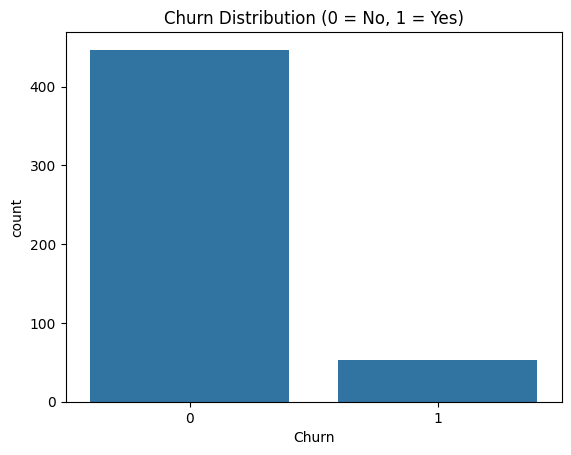

In [3]:
sns.countplot(x='Churn', data=churn_df)
plt.title('Churn Distribution (0 = No, 1 = Yes)')
plt.show()

## 3. Data Preprocessing
Encoding categorical variables and dropping CustomerID.

In [4]:
# Drop CustomerID
df = churn_df.drop('CustomerID', axis=1)

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['Contract', 'PaymentMethod', 'PaperlessBilling'], drop_first=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Model Development
Training a Random Forest Classifier.

In [5]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 5. Model Evaluation
Evaluating the model performance.

Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        84
           1       0.93      0.81      0.87        16

    accuracy                           0.96       100
   macro avg       0.95      0.90      0.92       100
weighted avg       0.96      0.96      0.96       100



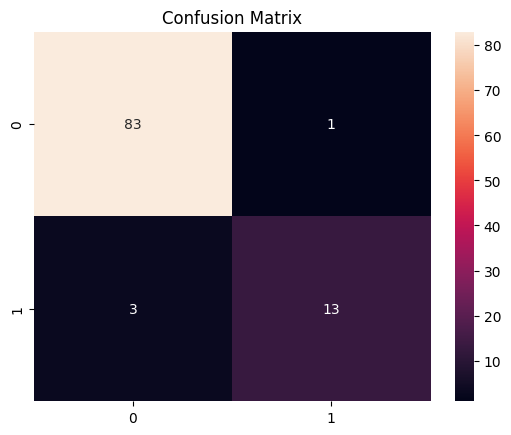

In [6]:
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

## 6. Deployment Prep
Saving the trained model and the feature columns for deployment.

In [7]:
with open('deployment/model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('deployment/columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print('Model and columns saved successfully!')

Model and columns saved successfully!
